# SHAP Analysis — House Price Model

Loads the SHAP explainer and values saved by the `explainability` pipeline and produces visualizations.

In [1]:
import pickle
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

## Load SHAP artifacts

In [2]:
import numpy as np

# shap_values.pkl is a raw numpy array in the model's column order (best_cols)
with open("../data/08_reporting/shap_values.pkl", "rb") as f:
    shap_values_arr = pickle.load(f)

# IMPORTANT: feature order must match the ARRAY columns (best_cols), NOT the
# importance CSV (which is sorted by importance). Using the sorted order here
# would mislabel every feature in the plots.
with open("../data/06_models/best_cols.pkl", "rb") as f:
    feature_names = list(pickle.load(f))

# importance table (sorted) for the final summary cell
shap_importance = pd.read_csv("../data/08_reporting/shap_importance.csv")

# reproduce the exact 200-row sample the pipeline used, to colour the beeswarm by value
X_val = pd.read_parquet("../data/05_model_input/X_val_scaled.parquet")[feature_names]
X_sample = X_val.sample(n=shap_values_arr.shape[0], random_state=42)

# load explainer only for the baseline (expected) value
with open("../data/08_reporting/shap_explainer.pkl", "rb") as f:
    explainer = pickle.load(f)
base = np.ravel(explainer.expected_value)[0]

# reconstruct a SHAP Explanation object for plotting
shap_values = shap.Explanation(
    values=shap_values_arr,
    base_values=np.full(shap_values_arr.shape[0], base),
    data=X_sample.values,
    feature_names=feature_names,
)

print(f"SHAP values shape: {shap_values_arr.shape}")
print(f"Features (array order): {feature_names}")


SHAP values shape: (200, 15)
Features (array order): ['District', 'Type', 'EnergyCertificate', 'Parking', 'HasParking', 'ConstructionYear', 'Elevator', 'TotalRooms', 'NumberOfBedrooms', 'NumberOfBathrooms', 'LivingArea_log', 'TotalArea_log', 'GrossArea_log', 'BuiltArea_log', 'LotSize_log']


## Global feature importance (bar plot)

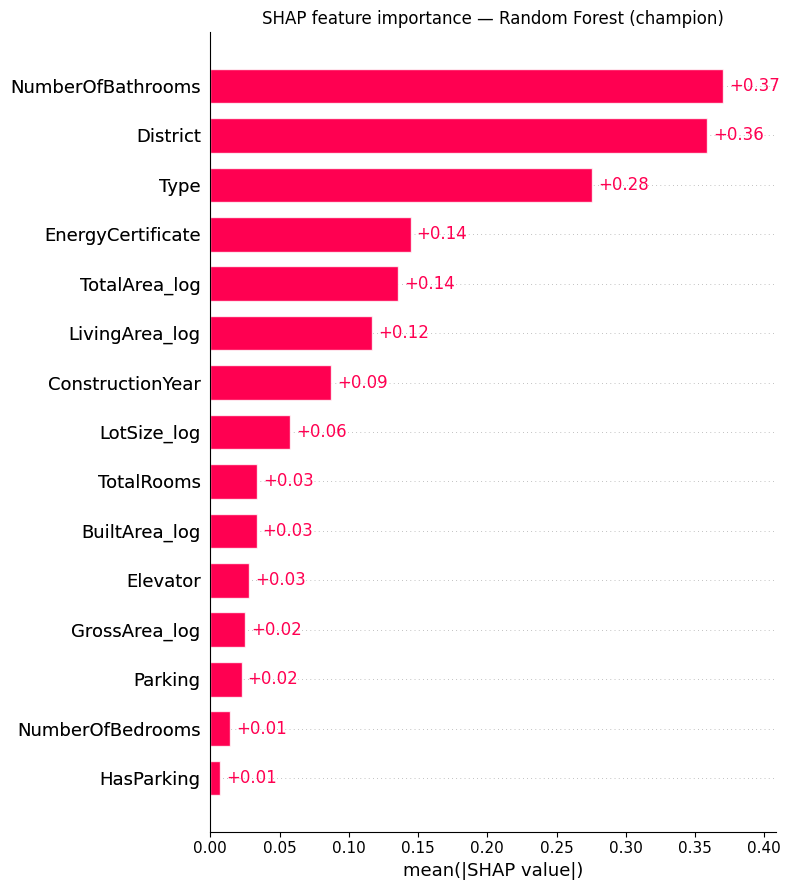

In [3]:
shap.plots.bar(shap_values, max_display=15, show=False)
import matplotlib.pyplot as plt
plt.title("SHAP feature importance — Random Forest (champion)")
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


## Beeswarm plot — impact and direction of each feature

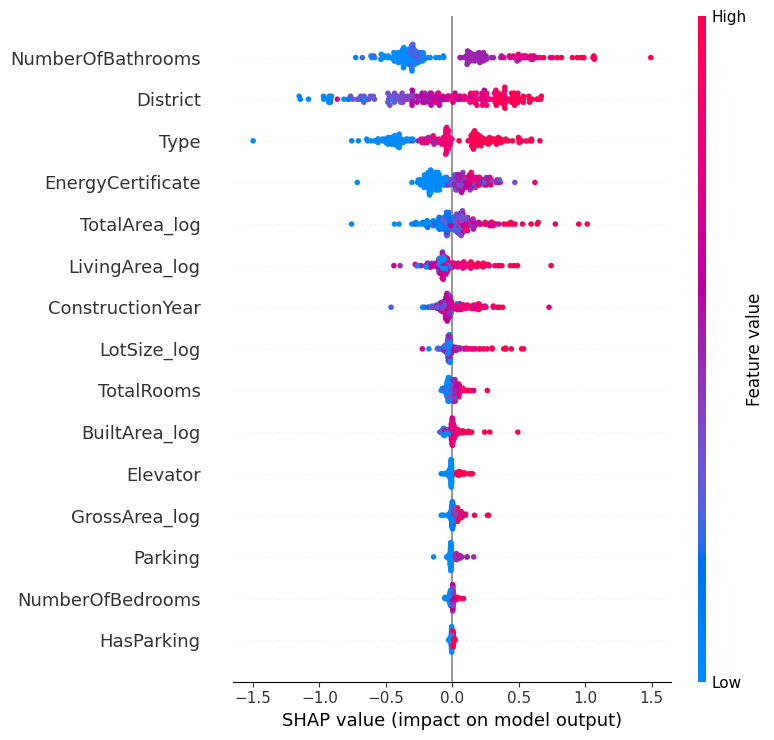

In [4]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


## Waterfall plot — explanation of an individual prediction

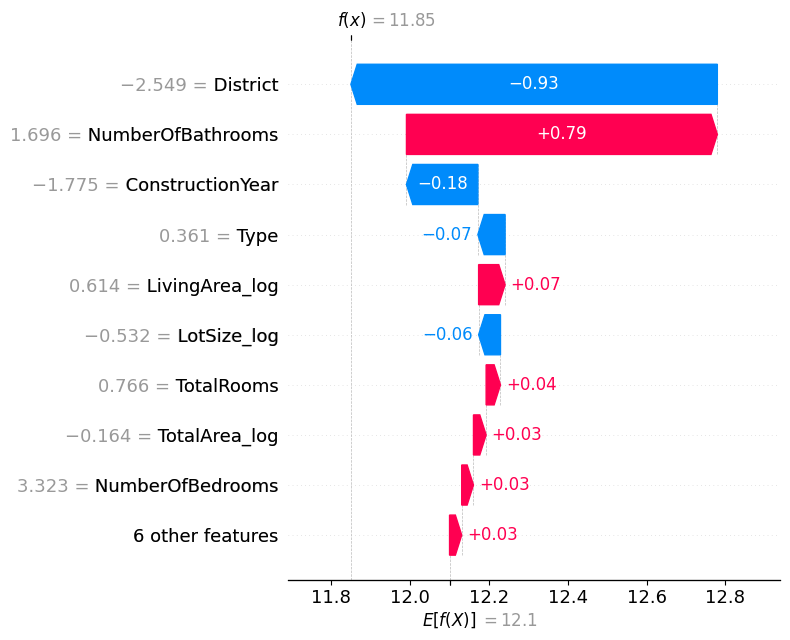

In [5]:
# change the index to explore other observations
idx = 0
shap.plots.waterfall(shap_values[idx], show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()


## Mean absolute SHAP importance per feature

In [6]:
shap_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

,feature,mean_abs_shap
0,NumberOfBathrooms,0.370489
1,District,0.358967
2,Type,0.275472
3,EnergyCertificate,0.144622
4,TotalArea_log,0.135346
5,LivingArea_log,0.116587
6,ConstructionYear,0.087349
7,LotSize_log,0.057361
8,TotalRooms,0.034029
9,BuiltArea_log,0.033333
